In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bharathk22520","key":"28634c135886be4caaadf7735e58879a"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!rm -f /content/*.zip
!kaggle datasets download -d shoybhasan/camus-human-heart-data -p /content --force

Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
100% 3.49G/3.50G [00:50<00:00, 32.1MB/s]
100% 3.50G/3.50G [00:50<00:00, 73.9MB/s]


In [6]:
!rm -rf /content/camus_data
!mkdir -p /content/camus_data
!unzip -q /content/camus-human-heart-data.zip -d /content/camus_data

In [7]:
!ls -lh /content | grep ".zip"

-rw-r--r-- 1 root root 3.5G Apr 14  2023 camus-human-heart-data.zip


In [8]:
!rm -rf /content/camus_full
!mkdir -p /content/camus_full
!unzip -q /content/camus_data/download -d /content/camus_full

In [9]:
import os

print(os.listdir("/content/camus_full")[:10])


['database_nifti']


In [10]:
import os
root_dir = "/content/camus_full/database_nifti"

print(len(os.listdir(root_dir)))
print(os.listdir(root_dir)[:5])

500
['patient0096', 'patient0239', 'patient0490', 'patient0370', 'patient0102']


In [11]:
!pip -q install nibabel segmentation-models-pytorch albumentations torchmetrics medpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 17.1 MB/s eta 0:00:00


In [12]:
import glob
import random
import numpy as np
import pandas as pd
import nibabel as nib
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from medpy.metric.binary import hd95

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Tesla T4 safe defaults
IMAGE_SIZE = 256
BATCH_SIZE = 4
LR = 1e-4
NUM_CLASSES = 4  # 0=BG, 1=LV, 2=MYO, 3=LA

Device: cuda


In [13]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
cv2.setNumThreads(0)
torch.set_num_threads(1)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print("Thread + cuDNN safe settings applied.")

Thread + cuDNN safe settings applied.


In [14]:
def get_patient_dirs(root_dir):
    return sorted([
        d for d in os.listdir(root_dir)
        if d.startswith("patient") and os.path.isdir(os.path.join(root_dir, d))
    ])

def get_image_mask_pairs(root_dir):
    images, masks = [], []
    patient_dirs = get_patient_dirs(root_dir)

    for p in patient_dirs:
        p_path = os.path.join(root_dir, p)

        for view in ["2CH", "4CH"]:
            for phase in ["ED", "ES"]:
                img = glob.glob(os.path.join(p_path, f"*_{view}_{phase}.nii.gz"))
                gt  = glob.glob(os.path.join(p_path, f"*_{view}_{phase}_gt.nii.gz"))

                if img and gt:
                    images.append(img[0])
                    masks.append(gt[0])

    return images, masks

patient_dirs = get_patient_dirs(root_dir)
images, masks = get_image_mask_pairs(root_dir)

print("Patient folders:", len(patient_dirs))
print("Total image-mask pairs:", len(images))
print("Example image:", images[0])
print("Example mask :", masks[0])

Patient folders: 500
Total image-mask pairs: 2000
Example image: /content/camus_full/database_nifti/patient0001/patient0001_2CH_ED.nii.gz
Example mask : /content/camus_full/database_nifti/patient0001/patient0001_2CH_ED_gt.nii.gz


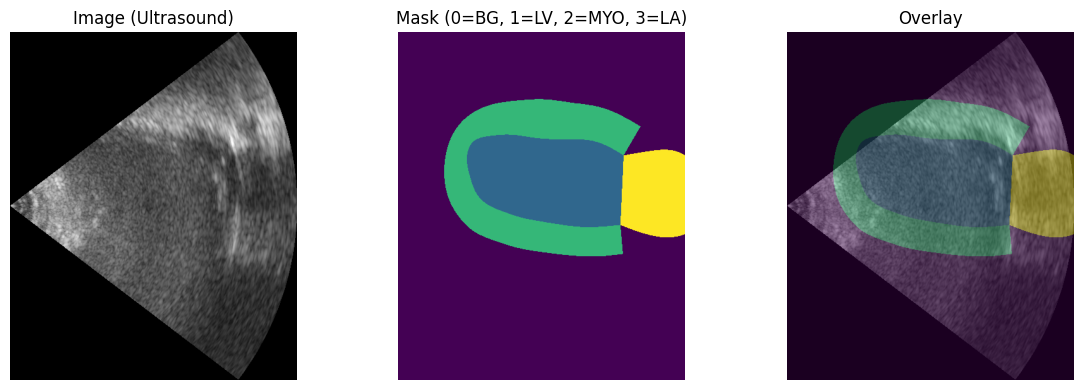

Sample file: patient0438_2CH_ED.nii.gz
Unique labels: [0. 1. 2. 3.]


In [15]:
idx = random.randint(0, len(images)-1)

img = nib.load(images[idx]).get_fdata()
msk = nib.load(masks[idx]).get_fdata()

if img.ndim == 3: img = img[:, :, 0]
if msk.ndim == 3: msk = msk[:, :, 0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image (Ultrasound)")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask (0=BG, 1=LV, 2=MYO, 3=LA)")
plt.imshow(msk)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(img, cmap="gray")
plt.imshow(msk, alpha=0.4)
plt.axis("off")

plt.tight_layout()
plt.show()

print("Sample file:", os.path.basename(images[idx]))
print("Unique labels:", np.unique(msk))

Pixel counts (subset): Counter({0: 82343721, 1: 8611328, 2: 8507561, 3: 4995280})


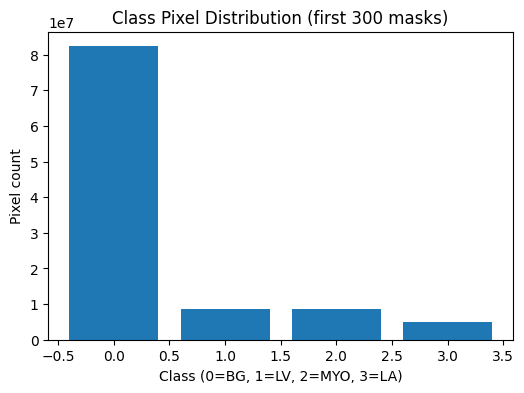

In [16]:
from collections import Counter

N = min(300, len(masks))
counter = Counter()

for mpath in masks[:N]:
    m = nib.load(mpath).get_fdata()
    if m.ndim == 3:
        m = m[:, :, 0]
    uniq, cnt = np.unique(m.astype(np.int64), return_counts=True)
    for u, c in zip(uniq, cnt):
        counter[int(u)] += int(c)

print("Pixel counts (subset):", counter)

plt.figure(figsize=(6,4))
plt.bar(counter.keys(), counter.values())
plt.title(f"Class Pixel Distribution (first {N} masks)")
plt.xlabel("Class (0=BG, 1=LV, 2=MYO, 3=LA)")
plt.ylabel("Pixel count")
plt.show()

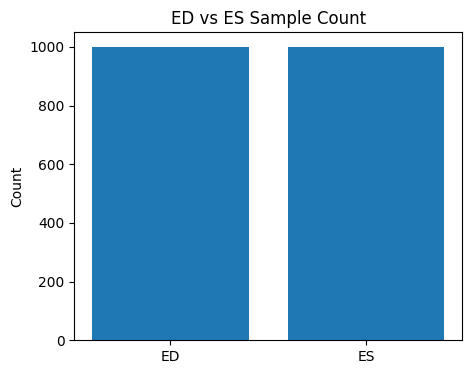

ED: 1000 ES: 1000


In [17]:
ed_count = sum("_ED.nii.gz" in p for p in images)
es_count = sum("_ES.nii.gz" in p for p in images)

plt.figure(figsize=(5,4))
plt.bar(["ED", "ES"], [ed_count, es_count])
plt.title("ED vs ES Sample Count")
plt.ylabel("Count")
plt.show()

print("ED:", ed_count, "ES:", es_count)

In [18]:
class CamusNiftiDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, size=256):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # faster than get_fdata() sometimes
        img = np.asanyarray(nib.load(self.image_paths[idx]).dataobj)
        msk = np.asanyarray(nib.load(self.mask_paths[idx]).dataobj)

        if img.ndim == 3: img = img[:, :, 0]
        if msk.ndim == 3: msk = msk[:, :, 0]

        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        msk = cv2.resize(msk, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        msk = msk.astype(np.int64)  # keep 0/1/2/3

        if self.transform:
            out = self.transform(image=img.astype(np.float32), mask=msk)
            img = out["image"]
            msk = out["mask"].long()

        return img.float(), msk

In [19]:
transform = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

dataset = CamusNiftiDataset(images, masks, transform=transform, size=IMAGE_SIZE)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

# ----------------------------
# Balanced sampling (mitigation for background dominance)
# We oversample samples that contain more foreground pixels and/or LA pixels.
# ----------------------------
from torch.utils.data import WeightedRandomSampler

def compute_sample_weights(seg_subset, eps=1e-6):
    weights = []
    for i in range(len(seg_subset)):
        _, mask = seg_subset[i]  # mask: (H,W) with values {0,1,2,3}
        if torch.is_tensor(mask):
            m = mask.detach().cpu().numpy()
        else:
            m = np.array(mask)

        fg_ratio = (m != 0).mean()                 # any structure pixels
        has_la = (m == 3).any()                    # LA presence
        has_myo = (m == 2).any()
        has_lv = (m == 1).any()

        # Weight design: boost images with structures (especially LA) to reduce bias to background
        w = 1.0 + 5.0 * fg_ratio
        if has_la:  w += 2.0
        if has_myo: w += 1.0
        if has_lv:  w += 0.5

        weights.append(w + eps)

    return torch.DoubleTensor(weights)

train_weights = compute_sample_weights(train_ds)
sampler = WeightedRandomSampler(weights=train_weights,
                                num_samples=len(train_weights),
                                replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train:", len(train_ds), "Val:", len(val_ds))
print("Batch size:", BATCH_SIZE)
print("Balanced sampler enabled ✅ (foreground/LA-boosted)")


Train: 1600 Val: 400
Batch size: 4
Balanced sampler enabled ✅ (foreground/LA-boosted)


In [20]:
# FIRST diagnostic cell (random loader – BEFORE comparison)
train_loader_random = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

In [21]:
# SECOND diagnostic cell (comparison function)
from collections import Counter
import numpy as np
import pandas as pd

def compute_pixel_share(loader):
    cnt = Counter()
    for b, (_, y) in enumerate(loader):
        y = y.numpy()
        for cls in [0,1,2,3]:
            cnt[cls] += int((y == cls).sum())
        if b == 20:
            break

    total = sum(cnt.values())
    return {
        "BG": cnt[0]/total,
        "LV": cnt[1]/total,
        "MYO": cnt[2]/total,
        "LA": cnt[3]/total
    }

In [22]:
# THIRD diagnostic cell (actual comparison)
before_share = compute_pixel_share(train_loader_random)
after_share  = compute_pixel_share(train_loader)

comparison = pd.DataFrame({
    "Before": before_share,
    "After": after_share
})

comparison

,Before,After
BG,0.747793,0.747784
LV,0.098273,0.094042
MYO,0.105661,0.107450
LA,0.048274,0.050724


In [23]:
import numpy as np
from collections import Counter

cnt = Counter()

for b, (_, y) in enumerate(train_loader):
    y = y.numpy()
    for cls in [0,1,2,3]:
        cnt[cls] += int((y == cls).sum())
    if b == 20:
        break

total = sum(cnt.values())

print("\nPixel share in sampled batches:")
for cls, name in zip([0,1,2,3], ["BG","LV","MYO","LA"]):
    print(name, round(cnt[cls] / total, 4))


Pixel share in sampled batches:
BG 0.7489
LV 0.0941
MYO 0.1044
LA 0.0526


In [24]:
def model_unet():      # Paper 1 baseline + Paper 5 baseline
    return smp.Unet("resnet34", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

def model_deeplab():   # Paper 2 backbone
    return smp.DeepLabV3("resnet34", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

def model_resunet():   # Paper 4 backbone
    return smp.Unet("resnet50", encoder_weights="imagenet", in_channels=1, classes=NUM_CLASSES).to(device)

In [25]:
def soft_dice_loss(logits, targets, num_classes=NUM_CLASSES, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    targets_oh = torch.nn.functional.one_hot(targets, num_classes).permute(0,3,1,2).float()

    dims = (0,2,3)
    intersection = torch.sum(probs * targets_oh, dims)
    union = torch.sum(probs + targets_oh, dims)

    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice[1:].mean()  # ignore background

class CEPlusDice(nn.Module):
    def __init__(self, ce_weight=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.ce_weight = ce_weight

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + (1 - self.ce_weight) * soft_dice_loss(logits, targets)

In [26]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)   # prevents instability
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        # apply class weighting if alpha given
        if self.alpha is not None:
            at = self.alpha.gather(0, targets.view(-1)).view_as(targets)
            focal_loss = at * focal_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        else:
            return focal_loss.sum()


In [27]:
def dice_iou_for_class(pred, true, cls, eps=1e-8):
    pred_c = (pred == cls)
    true_c = (true == cls)
    inter = (pred_c & true_c).sum()
    dice = (2*inter) / (pred_c.sum() + true_c.sum() + eps)
    iou  = inter / (pred_c.sum() + true_c.sum() - inter + eps)
    return float(dice), float(iou)

def evaluate_fast(model, loader):
    model.eval()

    dices = {0: [], 1: [], 2: [], 3: []}
    ious  = {0: [], 1: [], 2: [], 3: []}

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            true = y.cpu().numpy()

            for b in range(pred.shape[0]):
                for cls in [0, 1, 2, 3]:   # include background
                    d, i = dice_iou_for_class(pred[b], true[b], cls)
                    dices[cls].append(d)
                    ious[cls].append(i)

    return {
        "Dice_BG": np.mean(dices[0]),
        "Dice_LV": np.mean(dices[1]),
        "Dice_MYO": np.mean(dices[2]),
        "Dice_LA": np.mean(dices[3]),
        "IoU_BG": np.mean(ious[0]),
        "IoU_LV": np.mean(ious[1]),
        "IoU_MYO": np.mean(ious[2]),
        "IoU_LA": np.mean(ious[3]),
    }

def evaluate_hd95_only(model, loader):
    model.eval()
    hds = {1: [], 2: [], 3: []}

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            true = y.cpu().numpy()

            for b in range(pred.shape[0]):
                for cls in [1, 2, 3]:
                    try:
                        if (pred[b] == cls).any() and (true[b] == cls).any():
                            hds[cls].append(
                                hd95((pred[b] == cls).astype(np.uint8),
                                     (true[b] == cls).astype(np.uint8))
                            )
                    except:
                        pass

    return {
        "HD95_LV": np.mean(hds[1]) if len(hds[1]) else np.nan,
        "HD95_MYO": np.mean(hds[2]) if len(hds[2]) else np.nan,
        "HD95_LA": np.mean(hds[3]) if len(hds[3]) else np.nan,
    }

In [28]:
import copy
import numpy as np

def train_model_best(model, loss_fn, epochs=3, lr=LR, log_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_score = -1.0

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0.0

        print(f"\n>>> Epoch {ep}/{epochs} started")

        for bi, (x, y) in enumerate(train_loader):
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = loss_fn(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()

            if (bi + 1) % log_every == 0:
                print(f"    batch {bi+1}/{len(train_loader)} | loss {total_loss/(bi+1):.4f}")

        metrics = evaluate_fast(model, val_loader)
        score = float(np.mean([metrics["Dice_LV"], metrics["Dice_MYO"], metrics["Dice_LA"]]))

        print(
            f">>> Epoch {ep} finished | Loss {total_loss/len(train_loader):.4f} | "
            f"Dice(LV) {metrics['Dice_LV']:.4f} | Dice(MYO) {metrics['Dice_MYO']:.4f} | Dice(LA) {metrics['Dice_LA']:.4f} | "
            f"AvgDice {score:.4f}"
        )

        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            print(f"     Best model saved (AvgDice {best_score:.4f})")

    model.load_state_dict(best_state)
    print(f"\n>>> Restored BEST epoch model | Best AvgDice: {best_score:.4f}")
    return model

In [29]:
class_weights = torch.tensor([0.2, 1.0, 1.0, 1.3], device=device)  # BG, LV, MYO, LA
ce_weighted = nn.CrossEntropyLoss(weight=class_weights)

# Focal Loss definition (use same class weights)
focal_loss_fn = FocalLoss(alpha=class_weights, gamma=2.0)

print("Weighted CE ready:", class_weights)

Weighted CE ready: tensor([0.2000, 1.0000, 1.0000, 1.3000], device='cuda:0')


In [30]:
torch.cuda.empty_cache()

EPOCHS = 3  # later change to 20 for final dissertation
results = {}

def run_one(name, model_fn, loss_fn):
    print(f"\n====================\n>>> Starting {name}\n====================")
    torch.cuda.empty_cache()

    m = model_fn()
    m = train_model_best(m, loss_fn, epochs=EPOCHS, log_every=100)

    print(f">>> {name} training done. Computing FAST metrics...")
    res = evaluate_fast(m, val_loader)

    print(f">>> {name} computing HD95 (slow)...")
    res.update(evaluate_hd95_only(m, val_loader))

    results[name] = res
    return m

# Paper 1 — UNet (weighted CE recommended)
m1 = run_one("Paper1_UNet", model_unet, ce_weighted)

# Paper 2 — DeepLabV3 (weighted CE recommended)
m2 = run_one("Paper2_DeepLabV3", model_deeplab, ce_weighted)

# Paper 3 — UNet + CE+Dice (keep as-is)
m3 = run_one("Paper3_UNet_CE+Dice", model_unet, CEPlusDice(0.5))

# Paper 4 — ResUNet (weighted CE recommended)
m4 = run_one("Paper4_ResUNet", model_resunet, ce_weighted)

# Paper 5 — UNet baseline (weighted CE recommended)
m5 = run_one("Paper5_UNet_Baseline", model_unet, ce_weighted)



>>> Starting Paper1_UNet


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]


>>> Epoch 1/3 started
    batch 100/400 | loss 0.9016
    batch 200/400 | loss 0.6967
    batch 300/400 | loss 0.5700
    batch 400/400 | loss 0.4932
>>> Epoch 1 finished | Loss 0.4932 | Dice(LV) 0.8959 | Dice(MYO) 0.7972 | Dice(LA) 0.7793 | AvgDice 0.8241
     Best model saved (AvgDice 0.8241)

>>> Epoch 2/3 started
    batch 100/400 | loss 0.2269
    batch 200/400 | loss 0.2126
    batch 300/400 | loss 0.2034
    batch 400/400 | loss 0.1957
>>> Epoch 2 finished | Loss 0.1957 | Dice(LV) 0.9061 | Dice(MYO) 0.7788 | Dice(LA) 0.8548 | AvgDice 0.8466
     Best model saved (AvgDice 0.8466)

>>> Epoch 3/3 started
    batch 100/400 | loss 0.1736
    batch 200/400 | loss 0.1685
    batch 300/400 | loss 0.1631
    batch 400/400 | loss 0.1580
>>> Epoch 3 finished | Loss 0.1580 | Dice(LV) 0.9014 | Dice(MYO) 0.7924 | Dice(LA) 0.8441 | AvgDice 0.8460

>>> Restored BEST epoch model | Best AvgDice: 0.8466
>>> Paper1_UNet training done. Computing FAST metrics...
>>> Paper1_UNet computing HD95 (slow)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


>>> Epoch 1/3 started
    batch 100/400 | loss 0.7181
    batch 200/400 | loss 0.5498
    batch 300/400 | loss 0.4614
    batch 400/400 | loss 0.4062
>>> Epoch 1 finished | Loss 0.4062 | Dice(LV) 0.0618 | Dice(MYO) 0.5380 | Dice(LA) 0.5020 | AvgDice 0.3673
     Best model saved (AvgDice 0.3673)

>>> Epoch 2/3 started
    batch 100/400 | loss 0.2290
    batch 200/400 | loss 0.2134
    batch 300/400 | loss 0.2073
    batch 400/400 | loss 0.1966
>>> Epoch 2 finished | Loss 0.1966 | Dice(LV) 0.9187 | Dice(MYO) 0.7977 | Dice(LA) 0.8579 | AvgDice 0.8581
     Best model saved (AvgDice 0.8581)

>>> Epoch 3/3 started
    batch 100/400 | loss 0.1611
    batch 200/400 | loss 0.1551
    batch 300/400 | loss 0.1517
    batch 400/400 | loss 0.1494
>>> Epoch 3 finished | Loss 0.1494 | Dice(LV) 0.7557 | Dice(MYO) 0.7391 | Dice(LA) 0.7711 | AvgDice 0.7553

>>> Restored BEST epoch model | Best AvgDice: 0.8581
>>> Paper4_ResUNet training done. Computing FAST metrics...
>>> Paper4_ResUNet computing HD95 

In [31]:
# RETRAIN ALL WITH FOCAL LOSS

m1_f = run_one("Paper1_UNet_Focal", model_unet, focal_loss_fn)

m2_f = run_one("Paper2_DeepLabV3_Focal", model_deeplab, focal_loss_fn)

m3_f = run_one("Paper3_UNet_CE+Dice_FocalReplace", model_unet, focal_loss_fn)

m4_f = run_one("Paper4_ResUNet_Focal", model_resunet, focal_loss_fn)

m5_f = run_one("Paper5_UNet_Baseline_Focal", model_unet, focal_loss_fn)


>>> Starting Paper1_UNet_Focal

>>> Epoch 1/3 started
    batch 100/400 | loss 0.1478
    batch 200/400 | loss 0.1011
    batch 300/400 | loss 0.0803
    batch 400/400 | loss 0.0680
>>> Epoch 1 finished | Loss 0.0680 | Dice(LV) 0.7865 | Dice(MYO) 0.6322 | Dice(LA) 0.4842 | AvgDice 0.6343
     Best model saved (AvgDice 0.6343)

>>> Epoch 2/3 started
    batch 100/400 | loss 0.0269
    batch 200/400 | loss 0.0262
    batch 300/400 | loss 0.0247
    batch 400/400 | loss 0.0239
>>> Epoch 2 finished | Loss 0.0239 | Dice(LV) 0.8708 | Dice(MYO) 0.7029 | Dice(LA) 0.7295 | AvgDice 0.7677
     Best model saved (AvgDice 0.7677)

>>> Epoch 3/3 started
    batch 100/400 | loss 0.0206
    batch 200/400 | loss 0.0211
    batch 300/400 | loss 0.0205
    batch 400/400 | loss 0.0201
>>> Epoch 3 finished | Loss 0.0201 | Dice(LV) 0.9017 | Dice(MYO) 0.7676 | Dice(LA) 0.8453 | AvgDice 0.8382
     Best model saved (AvgDice 0.8382)

>>> Restored BEST epoch model | Best AvgDice: 0.8382
>>> Paper1_UNet_Focal t

In [32]:
df = pd.DataFrame(results).T
df

,Dice_BG,Dice_LV,Dice_MYO,Dice_LA,IoU_BG,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA
Paper1_UNet,0.968149,0.906102,0.778833,0.854764,0.938564,0.832667,0.643696,0.761221,8.258238,10.452999,10.724307
Paper2_DeepLabV3,0.967249,0.897247,0.782805,0.863258,0.937005,0.817390,0.648717,0.773124,8.330444,11.713826,9.916052
Paper3_UNet_CE+Dice,0.980633,0.926784,0.848564,0.879960,0.962139,0.866216,0.740406,0.798906,6.457910,7.470165,9.066065
Paper4_ResUNet,0.967289,0.918682,0.797693,0.857941,0.936950,0.852690,0.667847,0.764860,7.479941,11.849215,12.213069
Paper5_UNet_Baseline,0.969549,0.916056,0.792816,0.857341,0.941103,0.847957,0.661596,0.760249,7.460608,10.193491,10.959182
Paper1_UNet_Focal,0.966686,0.901711,0.767622,0.845258,0.935814,0.825774,0.628010,0.756684,8.721026,12.186227,9.511211
Paper2_DeepLabV3_Focal,0.976312,0.891929,0.819140,0.859810,0.953915,0.810984,0.697561,0.770273,8.126482,8.709270,8.826721
Paper3_UNet_CE+Dice_FocalReplace,0.968314,0.908047,0.792208,0.851858,0.938813,0.834120,0.660711,0.753873,7.814754,11.118781,12.493928
Paper4_ResUNet_Focal,0.971670,0.913618,0.804485,0.854037,0.945129,0.844003,0.677567,0.758431,7.553268,10.506962,10.005168
Paper5_UNet_Baseline_Focal,0.972063,0.912130,0.821325,0.839190,0.945825,0.841274,0.701251,0.734792,7.664692,9.540837,13.431082


In [33]:
df["Mean_Dice"] = df[["Dice_LV","Dice_MYO","Dice_LA"]].mean(axis=1)
df["Mean_HD95"] = df[["HD95_LV","HD95_MYO","HD95_LA"]].mean(axis=1)
df.sort_values("Mean_Dice", ascending=False)

,Dice_BG,Dice_LV,Dice_MYO,Dice_LA,IoU_BG,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA,Mean_Dice,Mean_HD95
Paper3_UNet_CE+Dice,0.980633,0.926784,0.848564,0.879960,0.962139,0.866216,0.740406,0.798906,6.457910,7.470165,9.066065,0.885102,7.664713
Paper4_ResUNet,0.967289,0.918682,0.797693,0.857941,0.936950,0.852690,0.667847,0.764860,7.479941,11.849215,12.213069,0.858105,10.514075
Paper5_UNet_Baseline_Focal,0.972063,0.912130,0.821325,0.839190,0.945825,0.841274,0.701251,0.734792,7.664692,9.540837,13.431082,0.857548,10.212204
Paper4_ResUNet_Focal,0.971670,0.913618,0.804485,0.854037,0.945129,0.844003,0.677567,0.758431,7.553268,10.506962,10.005168,0.857380,9.355133
Paper2_DeepLabV3_Focal,0.976312,0.891929,0.819140,0.859810,0.953915,0.810984,0.697561,0.770273,8.126482,8.709270,8.826721,0.856960,8.554158
Paper5_UNet_Baseline,0.969549,0.916056,0.792816,0.857341,0.941103,0.847957,0.661596,0.760249,7.460608,10.193491,10.959182,0.855404,9.537760
Paper3_UNet_CE+Dice_FocalReplace,0.968314,0.908047,0.792208,0.851858,0.938813,0.834120,0.660711,0.753873,7.814754,11.118781,12.493928,0.850704,10.475821
Paper2_DeepLabV3,0.967249,0.897247,0.782805,0.863258,0.937005,0.817390,0.648717,0.773124,8.330444,11.713826,9.916052,0.847770,9.986774
Paper1_UNet,0.968149,0.906102,0.778833,0.854764,0.938564,0.832667,0.643696,0.761221,8.258238,10.452999,10.724307,0.846566,9.811848
Paper1_UNet_Focal,0.966686,0.901711,0.767622,0.845258,0.935814,0.825774,0.628010,0.756684,8.721026,12.186227,9.511211,0.838197,10.139488


In [34]:
df = df.sort_values("Mean_Dice", ascending=False)
df

,Dice_BG,Dice_LV,Dice_MYO,Dice_LA,IoU_BG,IoU_LV,IoU_MYO,IoU_LA,HD95_LV,HD95_MYO,HD95_LA,Mean_Dice,Mean_HD95
Paper3_UNet_CE+Dice,0.980633,0.926784,0.848564,0.879960,0.962139,0.866216,0.740406,0.798906,6.457910,7.470165,9.066065,0.885102,7.664713
Paper4_ResUNet,0.967289,0.918682,0.797693,0.857941,0.936950,0.852690,0.667847,0.764860,7.479941,11.849215,12.213069,0.858105,10.514075
Paper5_UNet_Baseline_Focal,0.972063,0.912130,0.821325,0.839190,0.945825,0.841274,0.701251,0.734792,7.664692,9.540837,13.431082,0.857548,10.212204
Paper4_ResUNet_Focal,0.971670,0.913618,0.804485,0.854037,0.945129,0.844003,0.677567,0.758431,7.553268,10.506962,10.005168,0.857380,9.355133
Paper2_DeepLabV3_Focal,0.976312,0.891929,0.819140,0.859810,0.953915,0.810984,0.697561,0.770273,8.126482,8.709270,8.826721,0.856960,8.554158
Paper5_UNet_Baseline,0.969549,0.916056,0.792816,0.857341,0.941103,0.847957,0.661596,0.760249,7.460608,10.193491,10.959182,0.855404,9.537760
Paper3_UNet_CE+Dice_FocalReplace,0.968314,0.908047,0.792208,0.851858,0.938813,0.834120,0.660711,0.753873,7.814754,11.118781,12.493928,0.850704,10.475821
Paper2_DeepLabV3,0.967249,0.897247,0.782805,0.863258,0.937005,0.817390,0.648717,0.773124,8.330444,11.713826,9.916052,0.847770,9.986774
Paper1_UNet,0.968149,0.906102,0.778833,0.854764,0.938564,0.832667,0.643696,0.761221,8.258238,10.452999,10.724307,0.846566,9.811848
Paper1_UNet_Focal,0.966686,0.901711,0.767622,0.845258,0.935814,0.825774,0.628010,0.756684,8.721026,12.186227,9.511211,0.838197,10.139488


In [35]:
print("\n===== BACKGROUND BIAS CHECK =====")
print(df[["Dice_BG","Dice_LV","Dice_MYO","Dice_LA"]])



===== BACKGROUND BIAS CHECK =====
                                   Dice_BG   Dice_LV  Dice_MYO   Dice_LA
Paper3_UNet_CE+Dice               0.980633  0.926784  0.848564  0.879960
Paper4_ResUNet                    0.967289  0.918682  0.797693  0.857941
Paper5_UNet_Baseline_Focal        0.972063  0.912130  0.821325  0.839190
Paper4_ResUNet_Focal              0.971670  0.913618  0.804485  0.854037
Paper2_DeepLabV3_Focal            0.976312  0.891929  0.819140  0.859810
Paper5_UNet_Baseline              0.969549  0.916056  0.792816  0.857341
Paper3_UNet_CE+Dice_FocalReplace  0.968314  0.908047  0.792208  0.851858
Paper2_DeepLabV3                  0.967249  0.897247  0.782805  0.863258
Paper1_UNet                       0.968149  0.906102  0.778833  0.854764
Paper1_UNet_Focal                 0.966686  0.901711  0.767622  0.845258


In [36]:
ce_models = df[df.index.str.contains("Paper") & ~df.index.str.contains("Focal")]
focal_models = df[df.index.str.contains("Focal")]

print("\n=== CE MODELS ===")
display(ce_models[["Mean_Dice","Mean_HD95"]])

print("\n=== FOCAL MODELS ===")
display(focal_models[["Mean_Dice","Mean_HD95"]])



=== CE MODELS ===


,Mean_Dice,Mean_HD95
Paper3_UNet_CE+Dice,0.885102,7.664713
Paper4_ResUNet,0.858105,10.514075
Paper5_UNet_Baseline,0.855404,9.537760
Paper2_DeepLabV3,0.847770,9.986774
Paper1_UNet,0.846566,9.811848



=== FOCAL MODELS ===


,Mean_Dice,Mean_HD95
Paper5_UNet_Baseline_Focal,0.857548,10.212204
Paper4_ResUNet_Focal,0.857380,9.355133
Paper2_DeepLabV3_Focal,0.856960,8.554158
Paper3_UNet_CE+Dice_FocalReplace,0.850704,10.475821
Paper1_UNet_Focal,0.838197,10.139488
